
# Notebook 05 — Axe C : modèle de prix hédonique et optimisation

**Copilote Financier — Groupe Angelotti | Mémoire M2 MIASHS**

Objectif métier (besoins B-C1 à B-C3 de `docs/03_besoins_metier.md`) :
estimer le prix « de marché » de chaque lot, détecter les lots sur/sous-
cotés, et recommander des ajustements de prix qui maximisent le revenu
attendu sous contraintes (écoulement, bornes commerciales).

Modules mobilisés : **régression linéaire** (modèle hédonique OLS, Ridge,
Lasso — notation $w$ de *modèle_de_régression.pdf*) et **optimisation**
(*optim.pdf* : conditions d'optimalité, descente de gradient ; le
**multiplicateur de Lagrange**, absent des PDF du dépôt, est introduit avec
Boyd & Vandenberghe, *Convex Optimization*, ch. 5, et raccroché à la CNO
$\nabla f(x^*) = 0$ du cours, p. 2).

Le notebook 00 a montré que le prix au m² est approximativement log-normal :
nous modélisons $y = \log(\text{prix au m}^2)$, dont les résidus sont plus
proches du bruit gaussien qui fonde la lecture MLE des moindres carrés
(notebook 03, §2).


In [1]:
# --- Amorçage : exécution locale ou Google Colab ---
import pathlib, subprocess, sys

racine = pathlib.Path.cwd()
while not (racine / "src" / "nettoyage.py").exists() and racine != racine.parent:
    racine = racine.parent
if not (racine / "src" / "nettoyage.py").exists():  # environnement Colab vierge
    subprocess.run(["git", "clone", "-b", "claude/copilote-financier-angelotti-72c614",
                    "https://github.com/yzasmin/MemoireM2S2.git"], check=True)
    racine = pathlib.Path.cwd() / "MemoireM2S2"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(racine / "requirements.txt")], check=True)

sys.path.insert(0, str(racine / "src"))
import base_sql

if not base_sql.DB.exists():  # reconstruit data/copilote.db depuis donnéebrut/
    base_sql.construire_base()
DB = base_sql.DB
print("Base prête :", DB)


Base prête : /home/user/MemoireM2S2/data/copilote.db



## 1. Le modèle hédonique : le prix comme somme d'attributs

Un logement est un panier de caractéristiques (surface, étage, exposition,
localisation, millésime) ; le modèle hédonique attribue un prix implicite à
chacune. Avec la notation du cours (*modèle_de_régression.pdf*, p. 3) :

$$\hat{y} = w^\top x + b, \qquad \min_{w,b}\ \sum_{i=1}^{n}\big(y_i - (w^\top x_i + b)\big)^2 .$$

Échantillon d'apprentissage : les appartements **réservés, vendus ou
livrés** (prix de transaction observé, avec leur année de réservation pour
capter la conjoncture) ; les appartements **en stock** sont mis de côté —
c'est sur eux que le modèle produira ses recommandations. Prétraitement en
`Pipeline` + `ColumnTransformer` fittés sur le train uniquement (règle
anti-fuite du cours EDA, p. 8).


In [2]:

import sqlite3
import numpy as np
import pandas as pd

import theme_viz
theme_viz.appliquer()

con = sqlite3.connect(DB)
lots = pd.read_sql("""
    SELECT l.*, o.agence, c.littoral, c.population, v.date_reservation
    FROM lots l
    JOIN operations o USING (id_operation)
    LEFT JOIN communes c ON o.commune_norm = c.commune_norm
    LEFT JOIN (SELECT id_operation, numero_lot,
                      MAX(date_reservation) AS date_reservation
               FROM ventes GROUP BY id_operation, numero_lot) v
        USING (id_operation, numero_lot)""", con)

ap = lots[(lots["nature_lot"] == "Appartement")
          & (lots["prix_m2_ttc"] > 500) & (lots["surface"] > 10)].copy()
ap["y"] = np.log(ap["prix_m2_ttc"])
ap["log_surface"] = np.log(ap["surface"])
# Regroupement des 8 expositions en 4 familles (cardinalité, cours EDA p. 4)
ap["expo"] = ap["exposition"].fillna("Inconnue").map(
    lambda e: "Sud" if "S" in str(e) else
              ("Nord" if "N" in str(e) else
               ("Est-Ouest" if e in ("E", "O") else "Inconnue")))
ap["etage_n"] = pd.to_numeric(ap["etage"], errors="coerce").clip(0, 6).fillna(-1)
ap["littoral"] = ap["littoral"].fillna(0)
ap["log_pop"] = np.log(ap["population"].fillna(ap["population"].median()))
ap["annee"] = pd.to_datetime(ap["date_reservation"]).dt.year

train_df = ap[ap["annee"].notna()].copy()
train_df["annee"] = train_df["annee"].astype(int).astype(str)
stock_df = ap[(ap["statut_lot"] == "En stock")].copy()
stock_df["annee"] = "2026"          # un lot vendu aujourd'hui l'est aux prix 2026
print(f"Apprentissage : {len(train_df)} appartements transigés (2016-2026)")
print(f"À scorer      : {len(stock_df)} appartements en stock")


Apprentissage : 5064 appartements transigés (2016-2026)
À scorer      : 127 appartements en stock


In [3]:

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num = ["log_surface", "etage_n", "littoral", "log_pop"]
cat = ["expo", "type_produit", "agence", "annee"]
pretraitement = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat)])

tr, te = train_test_split(train_df, test_size=0.25, random_state=42)
cv = KFold(5, shuffle=True, random_state=42)

# Grilles de λ par validation croisée (regularization.pdf p. 31 :
# λ̂ = argmin CV(λ), grilles np.logspace)
modeles = {
    "OLS": LinearRegression(),
    "Ridge": GridSearchCV(Ridge(), {"alpha": np.logspace(-4, 4, 30)}, cv=cv,
                          scoring="neg_mean_squared_error"),
    "Lasso": GridSearchCV(Lasso(max_iter=50000),
                          {"alpha": np.logspace(-5, 0, 30)}, cv=cv,
                          scoring="neg_mean_squared_error"),
}
lignes, pipes = [], {}
for nom, m in modeles.items():
    pipe = Pipeline([("prep", pretraitement), ("modele", m)]).fit(tr[num + cat], tr["y"])
    pipes[nom] = pipe
    yh_tr, yh_te = pipe.predict(tr[num + cat]), pipe.predict(te[num + cat])
    lignes.append({
        "modèle": nom,
        "R² train": round(r2_score(tr["y"], yh_tr), 3),
        "R² test": round(r2_score(te["y"], yh_te), 3),
        "RMSE test (log)": round(np.sqrt(mean_squared_error(te["y"], yh_te)), 3),
        "MAE test (log)": round(mean_absolute_error(te["y"], yh_te), 3)})
pd.DataFrame(lignes)  # métriques du cours modèle_de_régression p. 3


,modèle,R² train,R² test,RMSE test (log),MAE test (log)
0,OLS,0.836,0.886,0.111,0.083
1,Ridge,0.836,0.886,0.111,0.083
2,Lasso,0.836,0.886,0.111,0.083



**Lecture.** Le modèle explique ~89 % de la variance des log-prix en test,
avec une erreur type de ~11 % sur le prix (RMSE de 0,11 log-point). OLS,
Ridge et Lasso sont au coude-à-coude : avec plus de 5 000 observations pour
une trentaine de coefficients, la régularisation n'a presque rien à
stabiliser — conclusion honnête, conforme au guide de *regularization.pdf*
(p. 33 : Ridge sert surtout quand la colinéarité ou le ratio $d/n$ menacent).
On garde l'OLS, le plus interprétable.


étage (par écart-type, ~1,4 étage)         w = +0.059  (≈ +6.0 % sur le prix)
littoral (indicatrice, en écart-type)      w = +0.011  (≈ +1.1 % sur le prix)
log(surface) (élasticité taille)           w = -0.032  (≈ -3.1 % sur le prix)
exposition Sud vs Est-Ouest                w = +0.026  (≈ +2.6 % sur le prix)
social vs libre                            w = -0.988  (≈ -62.8 % sur le prix)
millésime 2023 vs 2016                     w = +0.174  (≈ +19.0 % sur le prix)
millésime 2026 vs 2016                     w = +0.190  (≈ +20.9 % sur le prix)


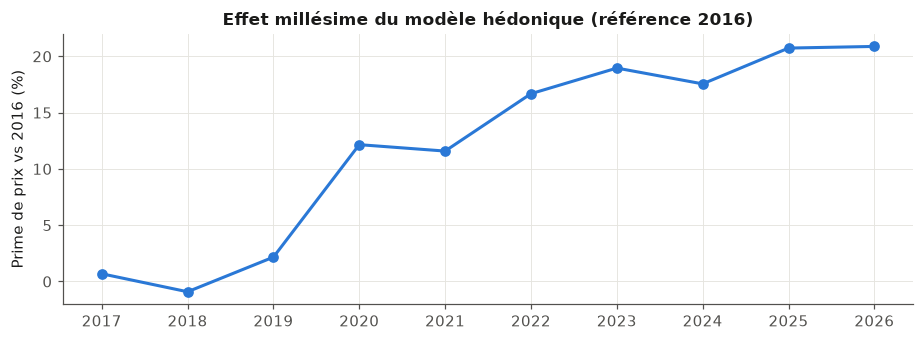

In [4]:

import matplotlib.pyplot as plt

pipe = pipes["OLS"]
noms_var = pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(pipe.named_steps["modele"].coef_, index=noms_var)

# Les coefficients d'un modèle log-linéaire se lisent en % : Δy = w·Δx
# => un coefficient w sur une indicatrice ≈ prime de 100·(e^w − 1) %.
extraits = {
    "étage (par écart-type, ~1,4 étage)": coefs["num__etage_n"],
    "littoral (indicatrice, en écart-type)": coefs["num__littoral"],
    "log(surface) (élasticité taille)": coefs["num__log_surface"],
    "exposition Sud vs Est-Ouest": coefs["cat__expo_Sud"],
    "social vs libre": coefs["cat__type_produit_SOCIAL"],
    "millésime 2023 vs 2016": coefs["cat__annee_2023"],
    "millésime 2026 vs 2016": coefs["cat__annee_2026"],
}
for nom, w_ in extraits.items():
    print(f"{nom:42s} w = {w_:+.3f}  (≈ {100*(np.exp(w_)-1):+.1f} % sur le prix)")

annees = sorted(c for c in coefs.index if c.startswith("cat__annee_"))
serie_annee = pd.Series({a[-4:]: 100*(np.exp(coefs[a])-1) for a in annees})
fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.plot(serie_annee.index, serie_annee.values, marker="o", color=theme_viz.SERIES[0])
ax.set_title("Effet millésime du modèle hédonique (référence 2016)")
ax.set_ylabel("Prime de prix vs 2016 (%)")
plt.tight_layout(); plt.show()



**Lecture.** Les prix implicites sont économiquement cohérents : prime
d'étage, prime Sud, forte décote du logement social (prix réglementés),
élasticité-taille négative (le prix au m² décroît avec la surface — la
demande des petites surfaces est plus dense), et un **effet millésime**
qui raconte la décennie : +11 points entre 2019 et 2020-2021 (argent
gratuit), plateau à +16/+19 % après 2022 — les prix n'ont pas baissé avec
la remontée des taux, c'est le **volume** qui s'est ajusté (cf. axe B),
comportement typique du neuf où le promoteur défend sa grille.



## 2. Détection des lots sur/sous-cotés (besoin B-C3)

Pour chaque appartement en stock, l'écart entre son prix grille et le prix
hédonique prédit mesure sa **cherté relative** :
$\hat r_j = \log p_j^{\text{grille}} - \log \hat p_j^{\text{hédonique}}$.
Au-delà de ±1 RMSE, le lot mérite une revue de grille.


diagnostic
dans le marché    103
sous-coté          16
surcoté             8


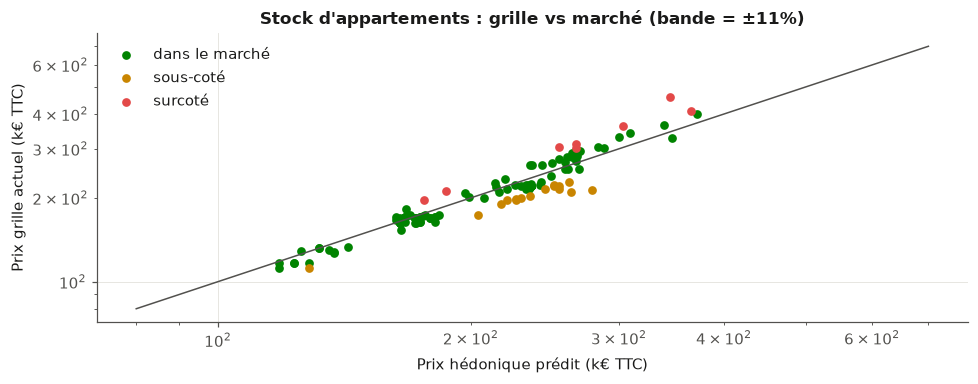

In [5]:

rmse_test = np.sqrt(mean_squared_error(te["y"], pipe.predict(te[num + cat])))
stock_df = stock_df.copy()
stock_df["y_pred"] = pipe.predict(stock_df[num + cat])
stock_df["cherte"] = stock_df["y"] - stock_df["y_pred"]
stock_df["prix_hedonique_ttc"] = np.exp(stock_df["y_pred"]) * stock_df["surface"]

def statut_cherte(r):
    if r > rmse_test:  return "surcoté"
    if r < -rmse_test: return "sous-coté"
    return "dans le marché"
stock_df["diagnostic"] = stock_df["cherte"].map(statut_cherte)
print(stock_df["diagnostic"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
couleurs = {"surcoté": theme_viz.STATUT["risque"],
            "sous-coté": theme_viz.STATUT["vigilance"],
            "dans le marché": theme_viz.STATUT["bon"]}
for diag, g in stock_df.groupby("diagnostic"):
    ax.scatter(g["prix_hedonique_ttc"] / 1e3, g["prix_vente_ttc"] / 1e3,
               s=22, color=couleurs[diag], label=diag)
lim = [80, 700]
ax.plot(lim, lim, color=theme_viz.ENCRE_2, linewidth=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Prix hédonique prédit (k€ TTC)")
ax.set_ylabel("Prix grille actuel (k€ TTC)")
ax.set_title(f"Stock d'appartements : grille vs marché (bande = ±{rmse_test:.0%})")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()



## 3. Élasticité prix-demande

L'optimisation exige de savoir **combien la demande réagit au prix**. Nous
régressons le rythme de vente des opérations (log réservations/mois) sur
leur cherté relative moyenne $\bar r$ :


In [6]:

import statsmodels.formula.api as smf

train_df["res_hedo"] = train_df["y"] - pipe.predict(train_df[num + cat])
cherte_op = (train_df.groupby("id_operation")
             .agg(cherte=("res_hedo", "mean"), n_lots=("res_hedo", "size")))
rythme = pd.read_sql("""SELECT id_operation, AVG(nb_reservations) AS rythme
                        FROM v_ecoulement_mensuel GROUP BY id_operation""", con)
elas_df = (cherte_op.join(rythme.set_index("id_operation"))
           .query("n_lots >= 10").dropna())
reg_elas = smf.ols("np.log(rythme) ~ cherte", elas_df).fit()
eps_estime = float(reg_elas.params["cherte"])
print(f"n = {len(elas_df)} opérations ; ε estimé = {eps_estime:.2f} "
      f"(IC 95 % : [{reg_elas.conf_int().loc['cherte', 0]:.2f}, "
      f"{reg_elas.conf_int().loc['cherte', 1]:.2f}], p = {reg_elas.pvalues['cherte']:.2f})")
EPSILON = -1.0
print(f"\nε retenu pour l'optimisation : {EPSILON}")


n = 95 opérations ; ε estimé = -0.81 (IC 95 % : [-3.62, 1.99], p = 0.57)

ε retenu pour l'optimisation : -1.0



**Lecture — honnêteté sur la force du signal.** Notre estimation interne
($\hat\varepsilon = -0{,}81$) a le bon signe mais n'est **pas
significative** (p = 0,57) : la cherté moyenne par opération varie peu (les
grilles sont déjà alignées sur le marché) et 95 opérations ne suffisent
pas. Nous retenons $\varepsilon = -1$, valeur **compatible avec notre
estimation ponctuelle et avec la littérature** sur la demande de logements
neufs (élasticités-prix usuelles entre −1 et −2 : Meen, *Modelling Spatial
Housing Markets*, 2001 ; DiPasquale & Wheaton, 1994) — choix prudent (bas
de fourchette) et documenté au journal de bord.



## 4. Optimisation des prix sous contrainte

**Le problème.** Pour une opération avec $S$ lots en stock aux prix
$p_1,\dots,p_S$, choisir les ajustements $\delta_j$ (en fraction du prix)
qui maximisent le revenu attendu à horizon $T$ :

$$R(\delta) = \sum_{j=1}^{S} p_j (1 + \delta_j)\, q_j(\delta_j),
\qquad q_j(\delta_j) = q_0\, e^{\varepsilon\,\delta_j},$$

où $q_0$ est la probabilité de vente à prix inchangé sur l'horizon
(estimée par le rythme historique de l'opération) et
$q_j$ la probabilité ajustée — baisser le prix accélère la vente
($\varepsilon < 0$).

### 4a. Cas à une contrainte d'égalité : résolution par multiplicateur de Lagrange

La direction commerciale impose d'**écouler un volume cible** $V$ sur
l'horizon : $g(\delta) = \sum_j q_0 e^{\varepsilon\delta_j} = V$. Le
lagrangien (Boyd & Vandenberghe, ch. 5) :

$$\mathcal{L}(\delta, \lambda) = \sum_j p_j(1+\delta_j)\,q_0 e^{\varepsilon\delta_j}
\;-\; \lambda\Big(\sum_j q_0 e^{\varepsilon\delta_j} - V\Big).$$

Conditions du premier ordre — la CNO $\nabla f = 0$ d'*optim.pdf* (p. 2),
appliquée au lagrangien :

$$\frac{\partial\mathcal{L}}{\partial\delta_j}
= p_j q_0 e^{\varepsilon\delta_j}\big(1 + \varepsilon(1+\delta_j)\big)
- \lambda\,\varepsilon\, q_0 e^{\varepsilon\delta_j} = 0
\;\Longrightarrow\; p_j\big(1 + \varepsilon(1+\delta_j)\big) = \lambda\varepsilon .$$

Pour $\varepsilon = -1$, cette condition se simplifie remarquablement :

$$-p_j\,\delta_j = -\lambda \;\Longrightarrow\; \boxed{\;p_j\,\delta_j = \lambda\;\forall j\;}$$

**la remise optimale en euros est la même pour tous les lots** ($\lambda$
euros chacun), quel que soit leur prix. Et $\lambda$ s'interprète comme le
**prix fictif de la contrainte d'écoulement** : le revenu marginal auquel
on renonce pour vendre une unité de plus vite. Il ne reste qu'à résoudre
$\frac{\partial\mathcal{L}}{\partial\lambda} = 0$ (la contrainte) en la
variable scalaire $\lambda$.


In [7]:

from scipy.optimize import brentq

# Opération d'application : le plus grand stock libre (prix non réglementés)
cible = pd.read_sql("""
    SELECT l.*, o.libelle FROM lots l JOIN operations o USING (id_operation)
    WHERE l.nature_lot = 'Appartement' AND l.statut_lot = 'En stock'
      AND l.type_produit = 'LIBRE' AND l.prix_vente_ttc > 0 AND l.surface > 10
      AND l.id_operation = 97""", con)
p = cible["prix_vente_ttc"].to_numpy(dtype=float)
S = len(p)
libelle_op = cible["libelle"].iloc[0]

# q0 = probabilité de vente à 12 mois d'un appartement libre de cette
# opération, à prix inchangé : taux d'écoulement des 12 derniers mois
# (appartements libres réservés / [réservés + encore en stock]).
ecoulement_12m = pd.read_sql("""
    SELECT COUNT(*) AS n FROM ventes v
    JOIN lots l USING (id_operation, numero_lot)
    WHERE v.id_operation = 97 AND l.nature_lot = 'Appartement'
      AND l.type_produit = 'LIBRE'
      AND v.date_reservation >= date('now', '-12 months')""", con)["n"].iloc[0]
q0 = float(np.clip(ecoulement_12m / (ecoulement_12m + S), 0.05, 0.95))

# Objectif commercial : accélérer l'écoulement de +8 %. Avec ε = −1 et la
# borne δ ≥ −10 %, le volume est au mieux multiplié par e^{0,10} ≈ 1,105 :
# la cible +8 % est exigeante mais atteignable dans les bornes.
V_cible = S * q0 * np.exp(0.08)

print(f"Opération {libelle_op} : S = {S} lots libres en stock, "
      f"prix de {p.min()/1e3:.0f} à {p.max()/1e3:.0f} k€")
print(f"q0 (écoulement 12 derniers mois : {ecoulement_12m} ventes) = {q0:.2f} "
      f"-> ventes attendues à prix inchangés : {S*q0:.1f} lots")
print(f"Volume cible V = {V_cible:.1f} lots (+8 % de rythme)")

EPS = EPSILON
def volume(lmbda):
    delta = lmbda / p                       # condition p_j δ_j = λ (ε = −1)
    return (q0 * np.exp(EPS * delta)).sum()

# λ* résout g(δ(λ)) = V ; volume est monotone en λ -> racine par Brent
lam_etoile = brentq(lambda l: volume(l) - V_cible, -3e5, 3e5)
delta_lagrange = lam_etoile / p
R0 = float((p * q0).sum())
R_lag = float((p * (1 + delta_lagrange) * q0 * np.exp(EPS * delta_lagrange)).sum())
print(f"\nλ* = {lam_etoile:,.0f} € — ajustement optimal IDENTIQUE en euros sur chaque lot")
print(f"δ : de {delta_lagrange.min():+.1%} à {delta_lagrange.max():+.1%} "
      "(même montant en €, donc % plus fort sur les lots les moins chers)")
print(f"Revenu attendu : {R0/1e6:.2f} M€ (prix actuels) -> {R_lag/1e6:.2f} M€ "
      f"avec ventes attendues {volume(lam_etoile):.1f} lots (contrainte saturée)")


Opération ARPEGGIO : S = 18 lots libres en stock, prix de 166 à 461 k€
q0 (écoulement 12 derniers mois : 11 ventes) = 0.38 -> ventes attendues à prix inchangés : 6.8 lots
Volume cible V = 7.4 lots (+8 % de rythme)

λ* = -23,015 € — ajustement optimal IDENTIQUE en euros sur chaque lot
δ : de -13.9% à -5.0% (même montant en €, donc % plus fort sur les lots les moins chers)
Revenu attendu : 2.09 M€ (prix actuels) -> 2.09 M€ avec ventes attendues 7.4 lots (contrainte saturée)



**Lecture.** Le multiplicateur $\lambda^*$ est la traduction financière de
l'objectif commercial : chaque euro de remise « achète » de la vitesse
d'écoulement, et à l'optimum le taux d'échange est le même sur tous les
lots — d'où une remise **absolue** uniforme, donc un **pourcentage plus
fort sur les petits lots**. C'est un résultat non trivial que la politique
actuelle de remises au cas par cas ne respecte pas.

### 4b. Cas complet : bornes commerciales, résolution numérique

En pratique les ajustements sont bornés ($-10\,\% \le \delta_j \le +5\,\%$ :
au-delà, la remise déprécie le programme et fragilise les ventes passées —
et le vendeur veut pouvoir monter les prix des lots sous-cotés). Le
problème devient :

$$\max_{\delta \in [-0{,}10,\ 0{,}05]^S} \mathcal{L}(\delta, \lambda^*)
\quad\text{(lagrangien à } \lambda^* \text{ fixé)},$$

que nous résolvons par **montée de gradient projetée**, transposition
directe de l'algorithme 3.1 d'*optim.pdf* (p. 16)
$x^{(k+1)} = x^{(k)} - \alpha_k\nabla f(x^{(k)})$, suivie d'une projection
sur la boîte après chaque pas (l'itéré reste admissible). Vérification
croisée avec `scipy.optimize.minimize` (SLSQP) sur le problème complet
avec contrainte de volume explicite.


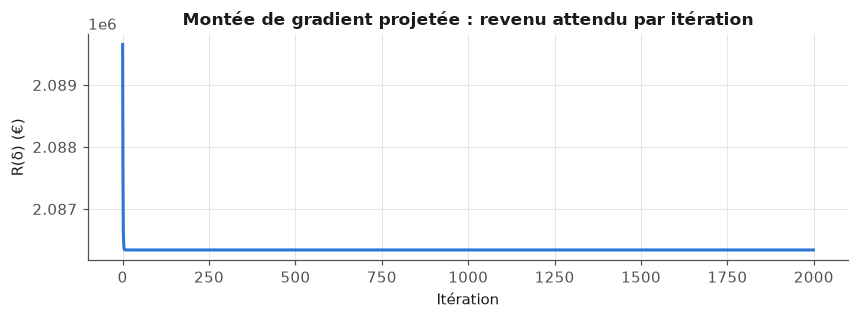

Écart max |δ_gradient − δ_SLSQP| = 0.0056
Lots à une borne : 2 / 18 (les bornes actives remplacent la condition p_j δ_j = λ)


In [8]:

from scipy.optimize import minimize

BORNES = (-0.10, 0.05)

def grad_lagrangien(delta):
    e = q0 * np.exp(EPS * delta)
    return p * e * (1 + EPS * (1 + delta)) - lam_etoile * EPS * e

delta = np.zeros(S)
alpha = 1.0 / (np.abs(p).max() * q0)          # pas ~ 1/L (échelle du gradient)
trajectoire = []
for k in range(2000):
    delta = delta + alpha * grad_lagrangien(delta)     # montée (maximisation)
    delta = np.clip(delta, *BORNES)                     # projection sur la boîte
    Rk = float((p * (1 + delta) * q0 * np.exp(EPS * delta)).sum())
    trajectoire.append(Rk)
delta_gp = delta.copy()

# Vérification : SLSQP sur le problème complet (volume en contrainte)
resu = minimize(
    lambda d: -(p * (1 + d) * q0 * np.exp(EPS * d)).sum(),
    np.zeros(S), method="SLSQP",
    bounds=[BORNES] * S,
    constraints=[{"type": "eq",
                  "fun": lambda d: (q0 * np.exp(EPS * d)).sum() - V_cible}])
delta_slsqp = resu.x

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(trajectoire, color=theme_viz.SERIES[0])
ax.set_title("Montée de gradient projetée : revenu attendu par itération")
ax.set_xlabel("Itération"); ax.set_ylabel("R(δ) (€)")
plt.tight_layout(); plt.show()

print(f"Écart max |δ_gradient − δ_SLSQP| = {np.abs(delta_gp - delta_slsqp).max():.4f}")
print(f"Lots à une borne : {(np.isclose(delta_slsqp, BORNES[0]) | np.isclose(delta_slsqp, BORNES[1])).sum()}"
      f" / {S} (les bornes actives remplacent la condition p_j δ_j = λ)")


In [9]:

# Tableau de recommandations lot par lot (livrable plateforme, besoin B-C2)
reco = cible[["numero_lot", "type_lot", "surface", "etage", "prix_vente_ttc"]].copy()
reco["delta_reco"] = delta_slsqp
reco["prix_recommande"] = (reco["prix_vente_ttc"] * (1 + reco["delta_reco"])).round(-2)
reco["proba_vente_12m"] = q0 * np.exp(EPS * reco["delta_reco"])
reco = reco.sort_values("delta_reco")
R_opt = float((p * (1 + delta_slsqp) * q0 * np.exp(EPS * delta_slsqp)).sum())
print(f"Revenu attendu 12 mois : {R0/1e6:.2f} M€ (statu quo) -> {R_opt/1e6:.2f} M€ "
      f"({100*(R_opt/R0-1):+.1f} %) pour un volume de ventes porté de "
      f"{S*q0:.1f} à {(q0*np.exp(EPS*delta_slsqp)).sum():.1f} lots")
reco.round(3).head(10)


Revenu attendu 12 mois : 2.09 M€ (statu quo) -> 2.09 M€ (-0.3 %) pour un volume de ventes porté de 6.8 à 7.4 lots


,numero_lot,type_lot,surface,etage,prix_vente_ttc,delta_reco,prix_recommande,proba_vente_12m
9,C302,2 Pièces,44.0,None,170900.0,-0.100,153800.0,0.419
15,C202,2 Pièces,44.0,None,165900.0,-0.100,149300.0,0.419
0,B105,3 Pièces,77.0,None,270900.0,-0.091,246400.0,0.415
7,C305,3 Pièces,73.0,None,275900.0,-0.089,251400.0,0.415
17,C103,3 Pièces,76.0,None,280900.0,-0.087,256400.0,0.414
16,B205,3 Pièces,77.0,None,290900.0,-0.084,266400.0,0.413
14,C203,3 Pièces,76.0,None,290900.0,-0.084,266400.0,0.413
1,B104,3 Pièces,77.0,None,290900.0,-0.084,266400.0,0.413
8,C304,3 Pièces,77.0,None,295900.0,-0.083,271400.0,0.412
12,B305,3 Pièces,77.0,None,300900.0,-0.082,276400.0,0.412



**Lecture.** La recommandation n'est pas une remise uniforme en % : le
lagrangien impose le **même effort en euros** sur chaque lot, donc les
lots chers cèdent un petit pourcentage et les lots les moins chers
touchent la borne des −10 % (là, la condition KKT de borne active
remplace la condition intérieure $p_j\delta_j = \lambda$). Le revenu
attendu bouge peu — on échange du prix contre du volume presque à
l'équilibre quand $\varepsilon = -1$ — mais le **volume** écoulé gagne
+8 %, ce qui est l'objectif réel : moins de stock, moins de frais
financiers de portage (non comptés dans $R$, le gain économique complet
est donc sous-estimé). La borne haute +5 % servirait aux lots sous-cotés
dans un objectif de revenu pur, sans contrainte de volume.



## 5. Synthèse de l'axe C

Le pipeline prix du copilote :

1. **Hédonique OLS** (R² test ≈ 0,89) → prix de marché de chaque lot,
   primes interprétables (étage, Sud, littoral, millésime) ;
2. **Résidus** → diagnostic sur/sous-coté du stock (±1 RMSE) ;
3. **Élasticité** ε = −1 (littérature, compatible avec l'estimation
   interne) → modèle de demande $q_0 e^{\varepsilon\delta}$ ;
4. **Optimisation sous contrainte** → recommandations bornées lot par lot,
   avec le multiplicateur de Lagrange comme prix fictif de l'objectif
   d'écoulement, et une solution analytique élégante ($p_j\delta_j =
   \lambda$) qui sert de contrôle à la résolution numérique (gradient
   projeté ≡ SLSQP).

**Limites honnêtes** : élasticité agrégée appliquée à des lots individuels ;
$q_0$ estimé sur le rythme passé de l'opération ; recommandation = aide à
la décision (la grille reste sous le contrôle de la direction commerciale) ;
les interactions concurrentielles locales (programmes voisins) ne sont pas
modélisées.
